In [1]:
# ------------------------------------------------------------
# KNN on Iris dataset (sklearn)
# Steps:
# 1) Load data
# 2) Visualize with labels (2 features)
# 3) Train-test split
# 4) Scale AFTER split using Pipeline
# 5) Train KNN
# 6) Evaluate
# ------------------------------------------------------------

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X shape: (150, 4)
y shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']


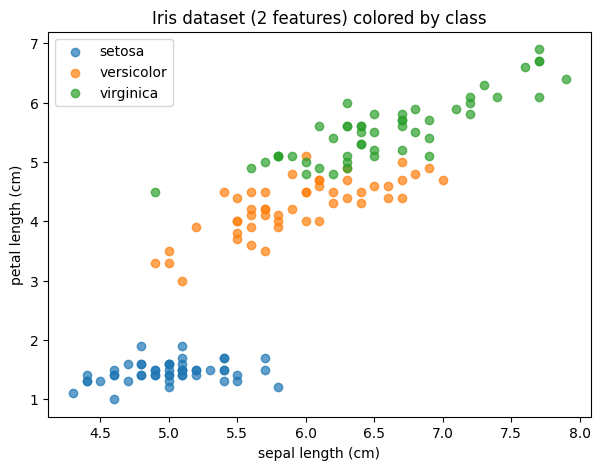

In [3]:
# 1) Load Iris
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", class_names)

f1, f2 = 0, 2

plt.figure(figsize=(7, 5))
for c in np.unique(y):
    plt.scatter(
        X[y == c, f1],
        X[y == c, f2],
        label=class_names[c],
        alpha=0.7
    )

plt.xlabel(feature_names[f1])
plt.ylabel(feature_names[f2])
plt.title("Iris dataset (2 features) colored by class")
plt.legend()
plt.show()

In [4]:
# 3) Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
# 4) Scaling AFTER split (no leakage) + 5) Train KNN using Pipeline
# Pipeline ensures scaler is fit ONLY on training data.
# K=5 is a common starting point.

knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

knn_pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])

In [6]:
# Optional: try different K values quickly
for k in [1, 3, 5, 7, 9]:
    pipe = Pipeline([("scaler", StandardScaler()),
                     ("knn", KNeighborsClassifier(n_neighbors=k))])
    pipe.fit(X_train, y_train)
    acc = pipe.score(X_test, y_test)
    print(f"K={k} -> Accuracy={acc:.3f}")

K=1 -> Accuracy=0.967
K=3 -> Accuracy=0.933
K=5 -> Accuracy=0.933
K=7 -> Accuracy=0.967
K=9 -> Accuracy=0.967


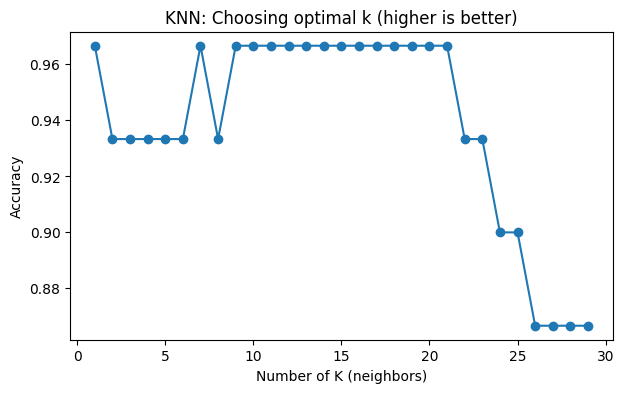

Best k = 1 with accuracy = 0.9666666666666667


In [7]:
# Try different k values and store accuracy
k_range = range(1, 30)
acc_scores = []

for k in k_range:
    knn_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    knn_pipeline.fit(X_train, y_train)
    acc_scores.append(knn_pipeline.score(X_test, y_test))  # accuracy on test set

# Plot k vs accuracy
plt.figure(figsize=(7, 4))
plt.xlabel("Number of K (neighbors)")
plt.ylabel("Accuracy")
plt.plot(k_range, acc_scores, marker="o")
plt.title("KNN: Choosing optimal k (higher is better)")
plt.show()

# Best k
best_k = k_range[int(np.argmax(acc_scores))]
best_acc = max(acc_scores)
print("Best k =", best_k, "with accuracy =", best_acc)